# Customer Churn Prediction — Exploratory Data Analysis

This notebook explores transactional purchase data to understand customer 
behavior, identify churn drivers, and establish a data-driven churn 
definition.

The analysis covers four areas:

- **Business health** — revenue trajectory, transaction quality, and 
  geographic distribution
- **Churn definition** — grounding the inactivity threshold in observed 
  interpurchase behavior
- **Behavioral analysis** — RFM distributions, segmentation, and 
  churned vs active comparison
- **Statistical validation** — formal tests confirming visual findings

All insights are derived from the full historical dataset with complete 
future visibility. In production, only past data would be available at 
prediction time. To prevent leakage, all features in the modeling stage 
are computed using time-based observation windows (this is addressed in 
the feature engineering notebook).

## Notebook structure

| Section | Content |
|---|---|
| 1. Setup | Libraries, constants, data loading |
| 2. Business health | Revenue, transaction types, geography |
| 3. Churn definition | Interpurchase analysis, RFM, threshold selection |
| 4. RFM analysis | Distributions, segmentation, behavioral comparison |
| 5. Seasonality investigation | Loyal segment anomaly, Q4 analysis |
| 6. Temporal dynamics | Cohort retention, tenure, engagement patterns |
| 7. Statistical validation | Formal tests confirming visual findings |
| 8. Conclusions and implications | Summary, hypotheses, candidate features |

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt, ticker
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency, kruskal
import os

# Output directories
os.makedirs("../reports/figures", exist_ok=True)

# Visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize']    = (12, 6)
plt.rcParams['axes.titlesize']    = 14
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.labelsize']    = 12

# Churn color palette
COLOR_RETAINED = "#4878CF"
COLOR_CHURNED  = "#D65F5F"
CHURN_PALETTE  = {0: COLOR_RETAINED, 1: COLOR_CHURNED}

In [2]:
retail_df = pd.read_parquet('../data/processed/online_retail_cleaned.parquet')

print("Dataset overview")
print("-" * 45)
print(f"  Rows:              {len(retail_df):,}")
print(f"  Unique customers:  {retail_df['CustomerID'].nunique():,}")
print(f"  Unique countries:  {retail_df['Country'].nunique()}")
print(f"  Date range:        {retail_df['InvoiceDate'].min().date()} → "
      f"{retail_df['InvoiceDate'].max().date()}")

Dataset overview
---------------------------------------------
  Rows:              797,815
  Unique customers:  5,939
  Unique countries:  41
  Date range:        2009-12-01 → 2011-12-09


## 2. Business Health

Before diving into customer-level churn analysis, we examine the overall 
business trajectory to understand revenue patterns and data quality. 
Three questions are addressed:

1. How does revenue trend over time and what seasonal patterns exist?
2. What is the quality of transaction data — how prevalent are returns 
   and voids?
3. Which markets drive revenue and why should analysis focus on the UK?

### 2.1 Revenue over time

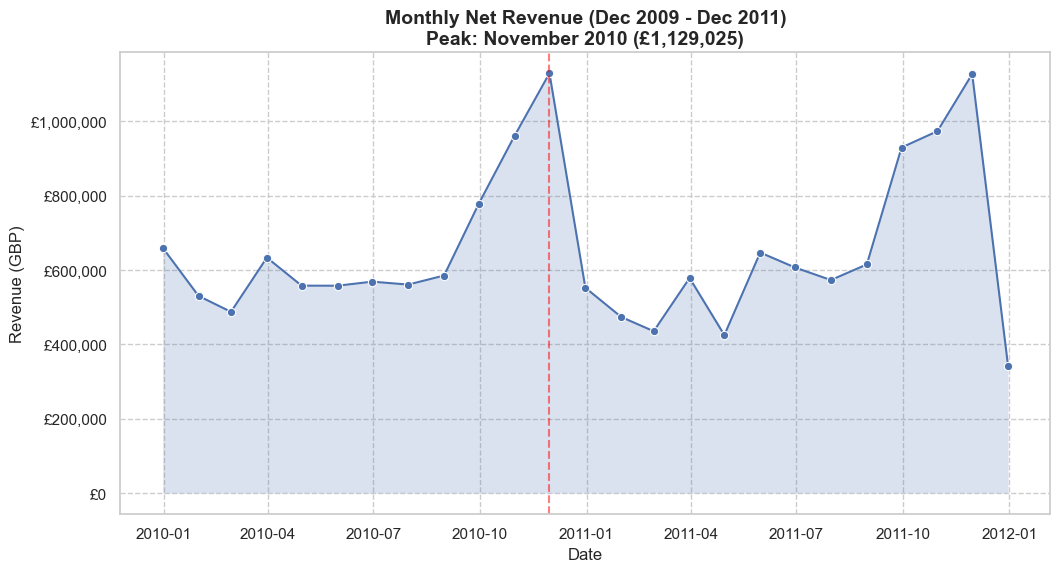

In [3]:
# Monthly revenue aggregation
monthly_revenue = retail_df.set_index('InvoiceDate')['TotalSum'].resample('ME').sum()

# Calculate peak metrics
peak_revenue = monthly_revenue.max()
peak_month = monthly_revenue.idxmax()

sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o')

plt.title(f'Monthly Net Revenue (Dec 2009 - Dec 2011)\nPeak: {peak_month.strftime('%B %Y')} (£{peak_revenue:,.0f})')
plt.xlabel('Date')
plt.ylabel('Revenue (GBP)')

plt.fill_between(monthly_revenue.index, monthly_revenue.values, alpha=0.2)
plt.axvline(peak_month, color='red', linestyle='--', alpha=0.5)

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('£{x:,.0f}')
)

plt.grid(True, linestyle='--')
plt.savefig("../reports/figures/monthly_revenue.png", bbox_inches="tight")
plt.show()

Revenue peaks sharply in **November** each year, driven by Q4 holiday 
purchasing. January shows a consistent post-holiday dip. This seasonal 
pattern has a direct implication for churn modeling. Customers who 
purchase primarily in Q4 may appear inactive under a fixed inactivity 
threshold during other months, potentially leading to false churn labels. 
This is investigated in section 5.

### 2.2 Transaction type distribution

Understanding transaction types is important for data quality. Returns 
and voids create negative revenue entries that can distort behavioral 
features if not handled correctly.

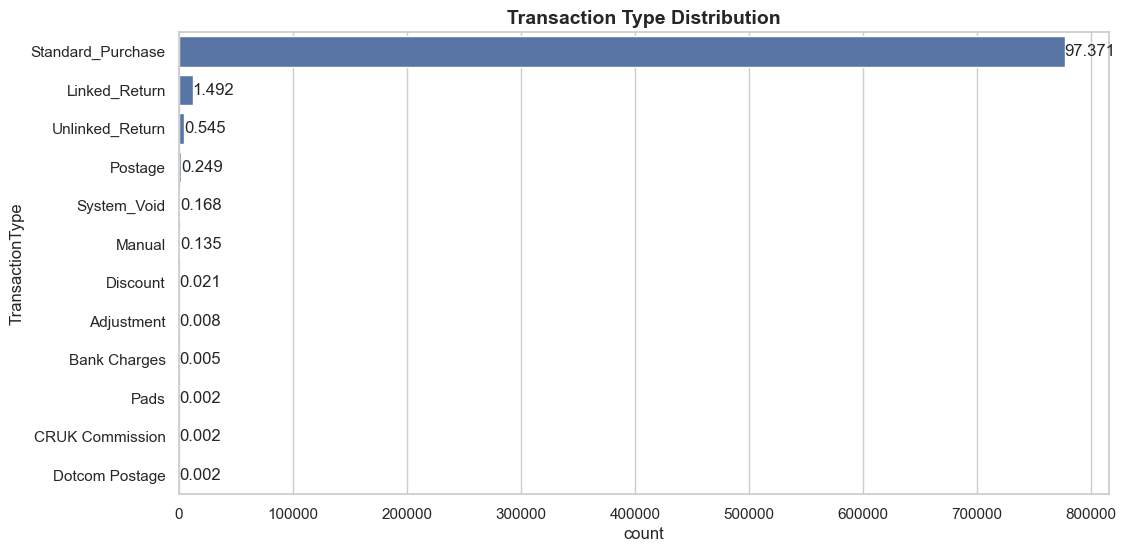

In [4]:
transaction_counts = retail_df['TransactionType'].value_counts(normalize=True)
transaction_percentages = round(transaction_counts * 100, 3)
ax = sns.countplot(
    data=retail_df,
    y='TransactionType',
    order=transaction_counts.index
)
ax.bar_label(container=ax.containers[0], labels=transaction_percentages)

plt.title('Transaction Type Distribution')
plt.show()

Standard purchases dominate at over 97% of transactions. Returns and 
voids form a small share but warrant attention for modeling:

- **Linked returns** (1.5%) — returns matched to a prior purchase within 
  30 days, likely reflecting genuine dissatisfaction
- **Unlinked returns** (0.5%) — returns without a matched purchase, 
  mainly capturing data limitations rather than customer behavior
- **System voids** — short-term cancellations within 60 minutes, 
  representing order corrections rather than true returns

For churn modeling, linked returns provide a mild dissatisfaction signal 
while system voids should be excluded from behavioral metrics. The low 
overall return rate means this feature will have limited predictive power 
(confirmed later in section 4).

### 2.3 Geographic revenue distribution

The dataset covers customers from multiple countries. Before conducting 
customer-level analysis, we assess whether focusing on a single market 
is justified.

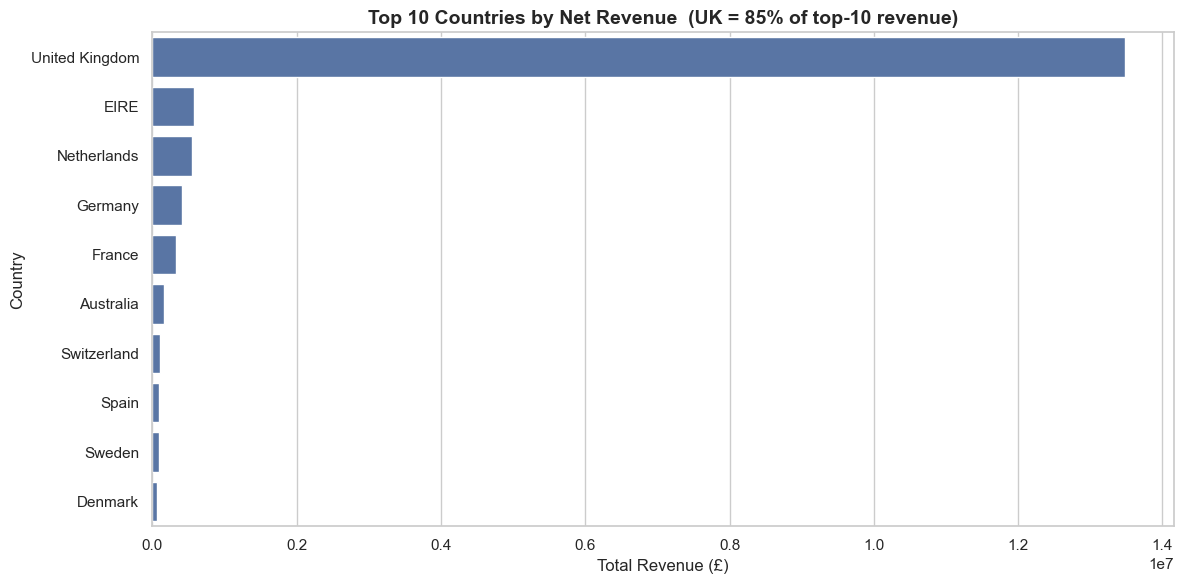

In [5]:
top_10_countries = (
    retail_df.groupby('Country', observed=True)['TotalSum']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_10_countries['Country'] = (
    top_10_countries['Country'].cat.remove_unused_categories()
)

uk_share = top_10_countries['TotalSum'].iloc[0] / top_10_countries['TotalSum'].sum()

sns.barplot(
    data=top_10_countries,
    x='TotalSum',
    y='Country',
    order=top_10_countries['Country'],
)
plt.title(f'Top 10 Countries by Net Revenue  '
          f'(UK = {uk_share:.0%} of top-10 revenue)')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig("../reports/figures/top_countries_revenue.png",
            bbox_inches="tight", dpi=150)
plt.show()

The UK accounts for approximately 85% of total revenue. Restricting the 
analysis to UK customers removes confounding factors (international 
shipping delays, varying return policies, and cross-country purchasing 
behavior) that would introduce noise into behavioral features without 
adding meaningful churn signal.

All subsequent analysis uses UK customers only.

In [6]:
uk_df = retail_df[retail_df['Country'] == 'United Kingdom'].copy()

print("UK customer dataset")
print("-" * 45)
print(f"  Customers:    {uk_df['CustomerID'].nunique():,}")
print(f"  Transactions: {len(uk_df):,}")
print(f"  Revenue:      £{uk_df['TotalSum'].sum():,.0f}")
print(f"  Date range:   {uk_df['InvoiceDate'].min().date()} → "
      f"{uk_df['InvoiceDate'].max().date()}")

UK customer dataset
---------------------------------------------
  Customers:    5,407
  Transactions: 716,069
  Revenue:      £13,482,505
  Date range:   2009-12-01 → 2011-12-09


## 3. Churn Definition

Before any behavioral analysis, a churn definition must be established. 
Rather than arbitrarily picking an inactivity threshold, the definition 
is grounded in observed customer behavior, specifically the distribution 
of time between consecutive purchases.

Three steps are followed:

1. Analyze the interpurchase time distribution to understand natural 
   purchase cadence
2. Compute RFM metrics as the basis for the static churn label
3. Test multiple inactivity thresholds and select one that is 
   behaviorally meaningful

### 3.1 Interpurchase time analysis

The distribution of days between consecutive purchases reveals the 
natural return cadence of UK customers and provides a behavioral 
foundation for the churn threshold.

Same-day intervals excluded: 95.9%


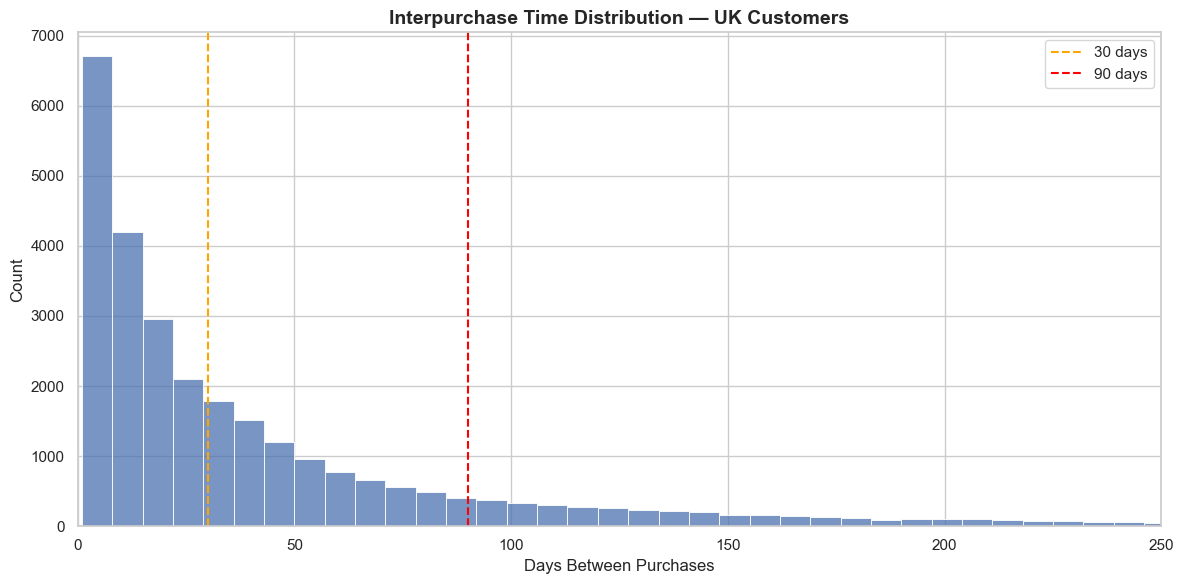

In [7]:
# Sort transactions chronologically per customer
uk_df_sorted = uk_df.sort_values(['CustomerID', 'InvoiceDate']).copy()

# Compute days between consecutive purchases
uk_df_sorted['PrevPurchase'] = (
    uk_df_sorted.groupby('CustomerID')['InvoiceDate'].shift(1)
)
uk_df_sorted['InterpurchaseDays'] = (
    uk_df_sorted['InvoiceDate'] - uk_df_sorted['PrevPurchase']
).dt.days

# Remove same-day transactions (split orders / multiple invoices per session)
interpurchase = uk_df_sorted['InterpurchaseDays'].dropna()
zero_pct = (interpurchase == 0).mean()
print(f"Same-day intervals excluded: {zero_pct:.1%}")
interpurchase = interpurchase[interpurchase > 0]

# Plot
sns.histplot(interpurchase, bins=100)
plt.title("Interpurchase Time Distribution — UK Customers")
plt.xlabel("Days Between Purchases")
plt.xlim(0, 250)
plt.axvline(30, color='orange', linestyle='--', label='30 days')
plt.axvline(90, color='red',    linestyle='--', label='90 days')
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/interpurchase_distribution.png",
            bbox_inches="tight", dpi=150)
plt.show()

The distribution is strongly right-skewed. Most customers who return 
do so quickly, with the probability of return declining steadily over 
time. A significant share of intervals occur within the same day due 
to split orders or multiple invoices per session, so these are excluded 
to focus on genuine revisit behavior.

Intervals beyond 90 days lie deep in the right tail, indicating that 
prolonged inactivity is genuinely uncommon. This provides behavioral 
grounding for a 90-day churn threshold — customers inactive beyond 
this point have exceeded the typical return window for the vast 
majority of the customer base.

### 3.2 RFM calculation

RFM metrics are computed at the customer level using the full 
transaction history. The snapshot date is set to one day after 
the last transaction, ensuring recency is measured relative to 
the end of the observation period.

Customers with zero or negative net monetary value are excluded. 
These typically represent return-only accounts with no genuine 
purchase history.

In [8]:
snapshot_date = uk_df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = uk_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days, # Recency
    'Invoice': 'nunique',                                          # Frequency
    'TotalSum': 'sum'                                              # Monetary
}).reset_index()

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

# Handle negative monetary customers
negative_count = (rfm['Monetary'] <= 0).sum()
print(f"Customers with negative balance: {negative_count} ({negative_count/len(rfm):.1%})")

rfm = rfm[rfm['Monetary'] > 0].copy()

Customers with negative balance: 89 (1.6%)


### 3.3 Threshold sensitivity analysis

Multiple inactivity thresholds are tested to understand how the 
churn rate responds to different definitions. The goal is to 
select a threshold that is behaviorally meaningful rather than 
one that optimizes class balance.

In [9]:
thresholds = [30, 60, 90, 120, 180]
for days in thresholds:
    churn_rate = (rfm['Recency'] > days).mean()
    print(f"{days:3d} days: {churn_rate:.1%} churned")

 30 days: 71.5% churned
 60 days: 58.6% churned
 90 days: 50.5% churned
120 days: 46.7% churned
180 days: 40.5% churned


The churn rate decreases non-linearly as the threshold increases
(from 71.5% at 30 days to 40.5% at 180 days). Even at the most 
conservative threshold (180 days), churn remains above 40%, 
suggesting the dataset contains a substantial proportion of 
customers who do not return within any of the tested windows.

The interpurchase distribution makes clear that the meaningful 
drop-off in return probability occurs before 30 days, not at 90. 
By 90 days the distribution is already in its flat sparse tail.
Customers inactive this long have genuinely exceeded the normal 
return window for the vast majority of the base.

A **90-day threshold** is selected because:
- It sits well into the tail of the interpurchase distribution, 
  past the point where normal purchase variability explains inactivity
- It gives approximately 50% churn — reflecting the actual proportion 
  of customers who do not return within this window
- It aligns with common retail practice for defining lapsed customers

A 30-day threshold would be too sensitive, it captures normal 
gaps between purchases rather than genuine disengagement. A 180-day 
threshold delays detection too long for a quarterly retention cycle.

The persistently high churn rate across all thresholds suggests a 
potentially large proportion of one-time or low-frequency buyers 
in this dataset. This hypothesis is examined in section 4.

Note that this static definition is used only for EDA. The feature 
engineering notebook replaces it with a dynamic sliding window 
approach where churn is defined relative to future activity in 
each prediction window, which handles the one-time-buyer problem 
more robustly.

### 3.4 Churn definition

In [10]:
CHURN_THRESHOLD = 90
rfm['IsChurned'] = (rfm['Recency'] > CHURN_THRESHOLD).astype(int)

print(f"Selected Threshold: {CHURN_THRESHOLD} days")
print(f"\nClass balance")
print("-"*20)
print(f"Active: {1 - rfm['IsChurned'].mean():.1%}")
print(f"Churned: {rfm['IsChurned'].mean():.1%}")

Selected Threshold: 90 days

Class balance
--------------------
Active: 49.5%
Churned: 50.5%


### 3.5 Limitations of the static definition

This churn definition applies a fixed 90-day threshold at a single 
point in time. Three limitations are worth noting:

**Right-censoring** — customers near the end of the dataset have 
less opportunity to show future activity, which may inflate churn 
estimates for recent periods.

**Snapshot dependency** — churn is defined at one point in time 
rather than as a dynamic process. A customer inactive for 91 days 
who purchases on day 92 is labeled as churned despite returning.

**Seasonality distortion** — customers with irregular or seasonal 
purchasing patterns may be incorrectly labeled as churned during 
natural inactivity periods. The Loyal segment analysis in section 5 
illustrates this directly.

These limitations are addressed in the feature engineering notebook 
by adopting a sliding window approach where churn is defined relative 
to future activity within each observation window, eliminating 
right-censoring and enabling time-aware labeling.

## 4. RFM Analysis

With the churn definition established, this section examines the 
distribution of RFM metrics across the customer base and groups 
customers into behavioral segments.

Three questions are addressed:

1. How are Recency, Frequency, and Monetary distributed — and what 
   does the shape of each distribution reveal about the customer base?
2. What proportion of customers are one-time buyers, and how does 
   this relate to the high churn rate observed at all thresholds?
3. Do RFM-based segments behave as expected, and are there any 
   anomalies requiring investigation?

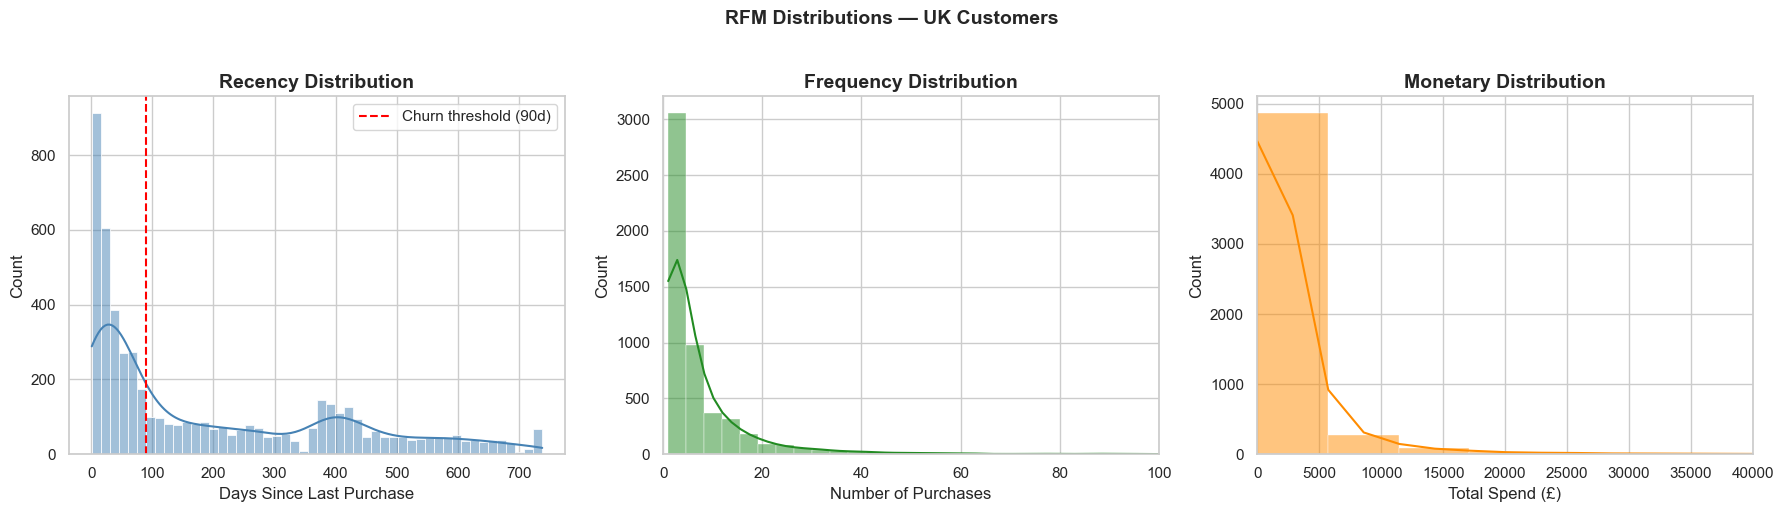

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=rfm, x='Recency', bins=50, kde=True,
             ax=axes[0], color='steelblue')
axes[0].axvline(CHURN_THRESHOLD, color='red', linestyle='--',
                label=f'Churn threshold ({CHURN_THRESHOLD}d)')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].legend()

sns.histplot(data=rfm, x='Frequency', bins=100, kde=True,
             ax=axes[1], color='forestgreen')
axes[1].set_xlim(0, 100)
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Purchases')

sns.histplot(data=rfm, x='Monetary', bins=100, kde=True,
             ax=axes[2], color='darkorange')
axes[2].set_xlim(0, 40000)
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spend (£)')

plt.suptitle('RFM Distributions — UK Customers',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/rfm_distributions.png",
            bbox_inches="tight", dpi=150)
plt.show()

All three RFM dimensions are strongly right-skewed, and each reveals 
something specific about the customer base.

**Recency** shows a bimodal pattern — a concentration of recently 
active customers (0–30 days) and a second smaller cluster around 
300–400 days. The 90-day churn threshold sits in the valley between 
these two groups, which provides stronger behavioral justification 
for the threshold choice than tail position alone: it naturally 
separates the recently active cluster from the long-inactive cluster.

**Frequency** makes the one-time buyer hypothesis from section 3 
visually explicit — the first bar (~1 purchase) is by far the largest, 
containing roughly 3,000 customers. The distribution drops sharply 
and becomes sparse beyond 10 purchases. This confirms that the 
persistently high churn rate across all thresholds is driven by 
a large one-time buyer population rather than threshold sensitivity.

**Monetary** is concentrated below £5,000–£7,500 for the vast 
majority of customers, with a very long sparse tail extending well 
beyond the plot range. A small number of high-value customers 
generate disproportionate revenue.

Together these distributions confirm that churn risk will concentrate 
among low-frequency, low-monetary customers who make up the bulk 
of the base, while a small high-value segment is likely to be 
retained.

### 4.1 One-time buyer analysis

The persistently high churn rate across all thresholds in section 3 
suggested a large proportion of customers who never return. This is 
tested directly here.

In [12]:
one_time   = (rfm['Frequency'] == 1).mean()
repeat     = 1 - one_time
churn_one  = rfm[rfm['Frequency'] == 1]['IsChurned'].mean()
churn_rep  = rfm[rfm['Frequency'] > 1]['IsChurned'].mean()

print("One-time vs repeat customers")
print("-" * 40)
print(f"  One-time buyers:  {one_time:.1%}")
print(f"  Repeat buyers:    {repeat:.1%}")
print()
print("Churn rate by buyer type")
print("-" * 40)
print(f"  One-time buyers:  {churn_one:.1%}")
print(f"  Repeat buyers:    {churn_rep:.1%}")

One-time vs repeat customers
----------------------------------------
  One-time buyers:  24.1%
  Repeat buyers:    75.9%

Churn rate by buyer type
----------------------------------------
  One-time buyers:  77.3%
  Repeat buyers:    42.1%


One-time buyers represent 24.1% of the customer base and churn at 
77.3%, more than double the rate of repeat buyers (42.1%). This 
confirms the hypothesis from section 3: the persistently high churn 
rate across all inactivity thresholds is partly driven by a 
substantial one-time buyer population who never return regardless 
of where the threshold is set.

However, one-time buyers alone do not fully explain the overall 
50.5% churn rate. Repeat buyers still churn at 42.1%, indicating 
that disengagement affects a large portion of the returning customer 
base as well. Churn is therefore not purely a new-customer problem, 
it is also a retention problem among customers who have already 
demonstrated willingness to return.

From a modeling perspective, one-time buyers are a structurally 
different population from churned repeat buyers. Early lifecycle 
features (purchases and spend in the first 30 days) are likely 
to be the strongest signal for this group, which is reflected in 
the feature set constructed in the feature engineering notebook.

### 4.2 RFM correlation

Before segmenting customers, it is useful to understand how the 
three RFM dimensions relate to each other. High correlations would 
indicate redundancy; low correlations confirm each dimension adds 
independent signal.

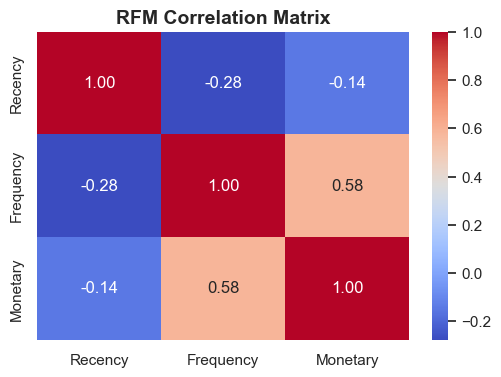

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(
    rfm[['Recency','Frequency','Monetary']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("RFM Correlation Matrix")
plt.show()

Frequency and Monetary show a moderate positive correlation (~0.58) — 
more active customers tend to spend more, but the relationship is 
not strong enough to make one redundant. Both dimensions capture 
distinct aspects of customer value.

Recency is only weakly correlated with Frequency (-0.28) and 
Monetary (-0.14), confirming that recent inactivity is not strongly 
tied to overall engagement history. A previously high-frequency 
customer can still churn and a low-frequency customer can still 
be recently active.

The three RFM components provide complementary information with 
limited redundancy, making them well-suited as a combined feature 
set for modeling.

### 4.3 RFM segmentation

Customers are grouped into behavioral segments using RFM quintile 
scores. Each dimension is scored 1–5, and segment labels are 
assigned using business-defined rules based on score combinations.

Segment labels follow common retail conventions but are treated 
as hypotheses. Actual behavior will be validated and labels 
refined if inconsistencies emerge.

In [14]:
rfm_seg = rfm.copy()

# Calculate Recency score (lower recency = higher score)
rfm_seg['R_Score'] = pd.qcut(
    rfm_seg['Recency'], 
    q=5, 
    labels=[5, 4, 3, 2, 1], 
    duplicates='drop'
).astype(int)

# Calculate Frequency score (higher frequency = higher score)
rfm_seg['F_Score'] = pd.qcut(
    rfm_seg['Frequency'].rank(method='first'), 
    q=5, 
    labels=[1, 2, 3, 4, 5], 
    duplicates='drop'
).astype(int)

# Calculate Monetary score (higher monetary = higher score)
rfm_seg['M_Score'] = pd.qcut(
    rfm_seg['Monetary'], 
    q=5, 
    labels=[1, 2, 3, 4, 5], 
    duplicates='drop'
).astype(int)

#### Segment rules

Segments are assigned based on R, F, and M score thresholds:

| Segment | Rule |
|---|---|
| Champions | R ≥ 4, F ≥ 4, M ≥ 4 |
| Loyal | F ≥ 4, M ≥ 4 |
| Potential Loyalists | R ≥ 4, F ≥ 3, M ≥ 3 |
| Cannot Lose Them | R ≤ 2, F ≥ 4, M ≥ 4 |
| At Risk | R ≤ 2, F ≥ 3, M ≥ 3 |
| Need Attention | R ≥ 3, F ≤ 2 or M ≤ 2 |
| Hibernating | R ≤ 2, F ≤ 2, M ≤ 2 |
| New Customers | R ≥ 4 (else) |
| Other | Remaining customers |

In [15]:
# Define segment mapping function
def get_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    # High-value segments
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    if f >= 4 and m >= 4:
        return 'Loyal'
    if r >= 4 and f >= 3 and m >= 3:
        return 'Potential Loyalists'
    
    # At-risk segments
    if r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    if r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    
    # Low engagement segments
    if r >= 3 and (f <= 2 or m <= 2):
        return 'Need Attention'
    if r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    
    # Other segments
    if r >= 4:
        return 'New Customers'
    
    return 'Other'

# Apply segmentation
rfm_seg['Segment'] = rfm_seg.apply(get_segment, axis=1)

# Create segment summary
segment_summary = rfm_seg.groupby('Segment').agg({
    'CustomerID': 'count',
    'IsChurned': 'mean',
    'R_Score': 'mean',
    'F_Score': 'mean',
    'M_Score': 'mean'
}).round(2).rename(columns={
    'CustomerID': 'Count', 
    'IsChurned': 'Churn_Rate'
})

# Display segment summary
print("RFM SEGMENT ANALYSIS")
print("-"*70)
print(segment_summary.sort_values('Churn_Rate', ascending=False).to_string())

# Save
segment_summary.to_csv('../reports/rfm_segment_analysis.csv')

RFM SEGMENT ANALYSIS
----------------------------------------------------------------------
                     Count  Churn_Rate  R_Score  F_Score  M_Score
Segment                                                          
At Risk                364        1.00     1.65     3.25     3.30
Hibernating           1171        1.00     1.40     1.41     1.40
Other                  631        0.84     2.12     2.78     2.86
Loyal                  586        0.68     2.55     4.40     4.43
Need Attention         972        0.23     3.76     1.94     1.91
Champions             1170        0.00     4.59     4.69     4.66
Potential Loyalists    424        0.00     4.44     3.34     3.30


### 4.4 Segment distribution and churn rates

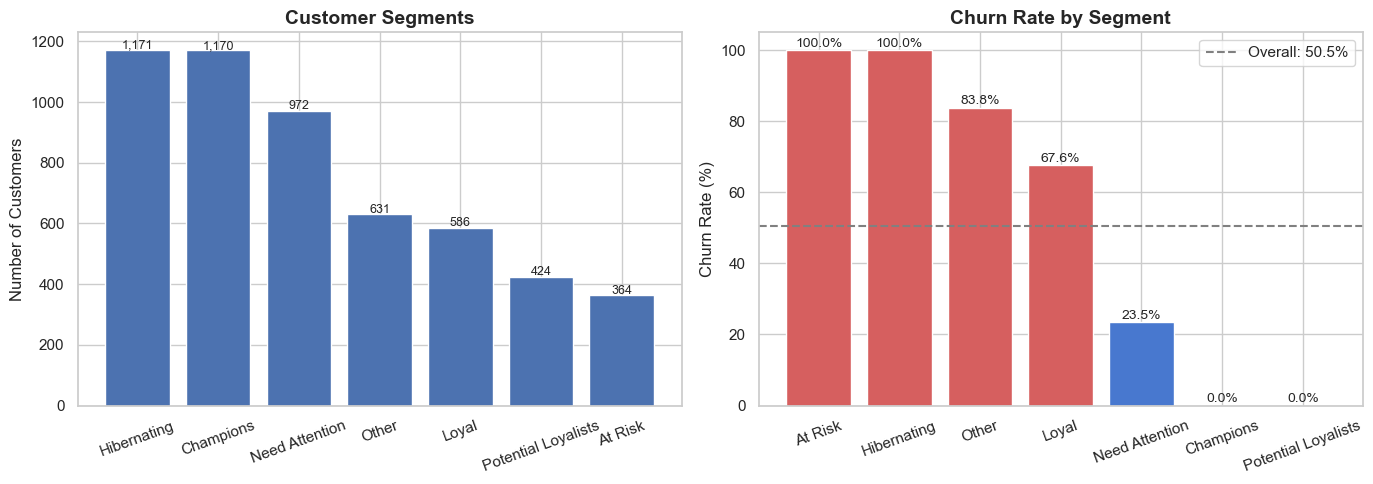

In [16]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Segment size distribution
seg_counts = rfm_seg['Segment'].value_counts()
bars = axes[0].bar(seg_counts.index, seg_counts.values)
axes[0].set_title('Customer Segments')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=20)

# Add value labels
for bar, val in zip(bars, seg_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 5, 
        f'{val:,}', 
        ha='center', 
        fontsize=9
    )

# Plot 2: Churn rate by segment
churn_by_seg = rfm_seg.groupby('Segment')['IsChurned'].mean().sort_values(ascending=False)
colors = [CHURN_PALETTE[1] if x > 0.5 else CHURN_PALETTE[0] for x in churn_by_seg.values]
bars = axes[1].bar(churn_by_seg.index, churn_by_seg.values * 100, color=colors)
axes[1].axhline(
    y=rfm['IsChurned'].mean() * 100, 
    color='gray', 
    linestyle='--', 
    label=f'Overall: {rfm["IsChurned"].mean()*100:.1f}%'
)
axes[1].set_title('Churn Rate by Segment')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()

# Add value labels
for bar, val in zip(bars, churn_by_seg.values * 100):
    axes[1].text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 1, 
        f'{val:.1f}%', 
        ha='center', 
        fontsize=10
    )

plt.tight_layout()
plt.show()

Most segments behave as expected. At Risk and Hibernating show 100% 
churn by construction, their low recency scores place them entirely 
above the 90-day threshold. Champions and Potential Loyalists show 
0% churn, consistent with their high recency scores.

Three observations stand out:

**Need Attention** (972 customers, 23.5% churn) is the third largest 
segment and sits well below the overall average of 50.5%. Despite 
low frequency or monetary scores, their relatively high recency 
(R ≥ 3) keeps most below the 90-day threshold. This segment 
represents recently active but low-engagement customers (not yet 
churned but worth monitoring).

**The Other segment** (631 customers, 83.8% churn) is large and 
poorly defined, customers that do not fit cleanly into any named 
segment end up here. Its high churn rate suggests it captures a 
heterogeneous mix of disengaged customers.

**The Loyal segment** (586 customers, 67.6% churn) is the key 
anomaly. By definition these are high-frequency, high-monetary 
customers (the segment most expected to be retained). A 67.6% 
churn rate is counterintuitive and requires investigation. This 
is the subject of section 5.

## 5. Seasonality Investigation

Section 4 identified an anomaly: the Loyal segment (high-frequency, 
high-monetary customers) shows a 67.6% churn rate under the 90-day 
static definition. Two explanations are possible:

1. **True attrition** — these customers genuinely stopped purchasing
2. **Definition artifact** — the static 90-day window catches these 
   customers between purchase cycles, producing false churn labels

If Loyal customers are consistent year-round buyers, a snapshot taken 
at the end of the dataset will inevitably catch some of them in a 
natural gap between purchases. This section tests that hypothesis 
through seasonal purchase profile analysis and Q4 concentration 
metrics.

### 5.1 Data preparation

In [17]:
seasonality_df = uk_df.copy()

# Add the Month and IsQ4 columns
seasonality_df['Month'] = seasonality_df['InvoiceDate'].dt.month
seasonality_df['IsQ4'] = seasonality_df['Month'].isin([10, 11, 12])

# Merge segment data with transaction data
segment_transactions = seasonality_df.merge(rfm_seg[['CustomerID', 'Segment']], on='CustomerID')
segment_transactions['Month'] = segment_transactions['InvoiceDate'].dt.month

# Calculate the monthly by segment
monthly_by_segment = (segment_transactions.groupby(['Segment', 'Month'])
                     .size()
                     .reset_index(name='Count'))
monthly_by_segment['Pct'] = (monthly_by_segment.groupby('Segment')['Count']
                            .transform(lambda x: x / x.sum() * 100))

# Calculate Q4 concentration per customer
q4_concentration = segment_transactions.groupby(['CustomerID', 'Segment'])['IsQ4'].mean().reset_index()
q4_concentration.columns = ['CustomerID', 'Segment', 'Q4_Concentration']

# Define segment order and colors for visualization
segment_order = ['Champions', 'Loyal', 'Potential Loyalists', 'At Risk', 'Need Attention']

segment_colors = {
    'At Risk': '#E15759',
    'Need Attention': '#F28E2B',
    'Loyal': '#4E79A7',
    'Champions': '#B07AA1',
    'Potential Loyalists': '#FF9DA7'
}

### 5.2 Seasonal purchase profile by segment

If the Loyal segment's high churn rate is a definition artifact, 
their purchase activity should be distributed evenly across months, 
unlike seasonal shoppers who concentrate purchases in Q4.

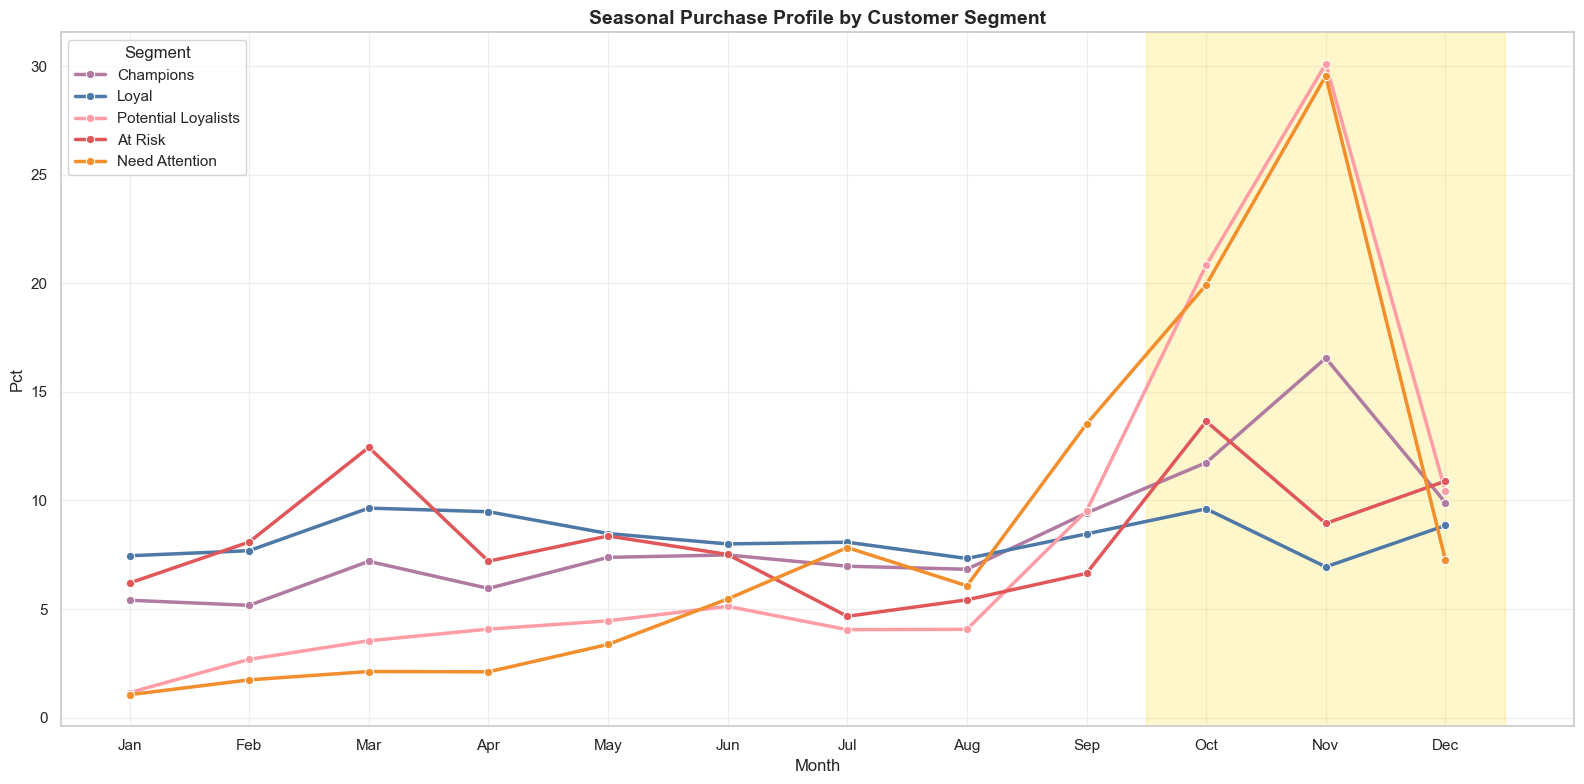

In [18]:
# Create plot
plt.figure(figsize=(16, 8))

sns.lineplot(data=monthly_by_segment,
             x='Month',
             y='Pct',
             hue='Segment',
             hue_order=segment_order,
             palette=segment_colors,
             marker='o',
             linewidth=2.5)

# Add Q4 highlight
plt.axvspan(9.5, 12.5, alpha=0.2, color='gold')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Seasonal Purchase Profile by Customer Segment')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/seasonality_by_segment.png", bbox_inches="tight")
plt.show()

The plot separates year-round buyers from seasonal shoppers clearly, 
and reveals a surprising pattern in the Need Attention segment.

**Loyal** (dark blue) remains the flattest line. Purchases stay 
between 7–10% every month with almost no variation and no Q4 spike. 
This is the behavioral signature of a genuine year-round buyer and 
directly explains the definition artifact: a 90-day snapshot taken 
at any point will catch some of these customers in a natural gap.

**Need Attention** (orange) is the most surprising finding. Despite 
having only 23.5% churn (well below the overall average) its 
seasonal profile is extreme in the chart, nearly identical 
to Potential Loyalists. Purchases are minimal outside Q4 (1–4% per 
month) then spike dramatically to ~30% in November. This suggests 
Need Attention customers are not low-engagement buyers, they are 
highly seasonal buyers whose activity is concentrated almost 
entirely in the holiday period.

**Potential Loyalists** (pink) show the same extreme Q4 pattern, 
nearly overlapping Need Attention in November. Together these two 
segments represent the clearest cases of episodic seasonal 
purchasing in the dataset.

**Champions** (purple) show a mild Q4 uptick but remain active 
throughout the year — consistent with their high recency and 
frequency scores.

**At Risk** (red) shows moderate Q4 concentration with slightly 
elevated activity in March, reflecting customers who were once 
seasonally engaged but have since lapsed.

The contrast between Loyal and Need Attention is particularly 
revealing: Loyal has a high churn rate (67.6%) despite the flattest 
seasonal profile, while Need Attention has a low churn rate (23.5%) 
despite the most extreme seasonal concentration. This inversion 
suggests that seasonality and churn are not directly linked,
what drives Loyal's high churn rate is the timing of the snapshot 
relative to their year-round purchase cycle, not disengagement.

### 5.3 Q4 concentration by segment

To quantify the seasonality difference across segments, the 
proportion of each customer's purchases occurring in Q4 
(October–December) is calculated. A high Q4 concentration 
indicates seasonal behavior; a low concentration indicates 
year-round consistency.

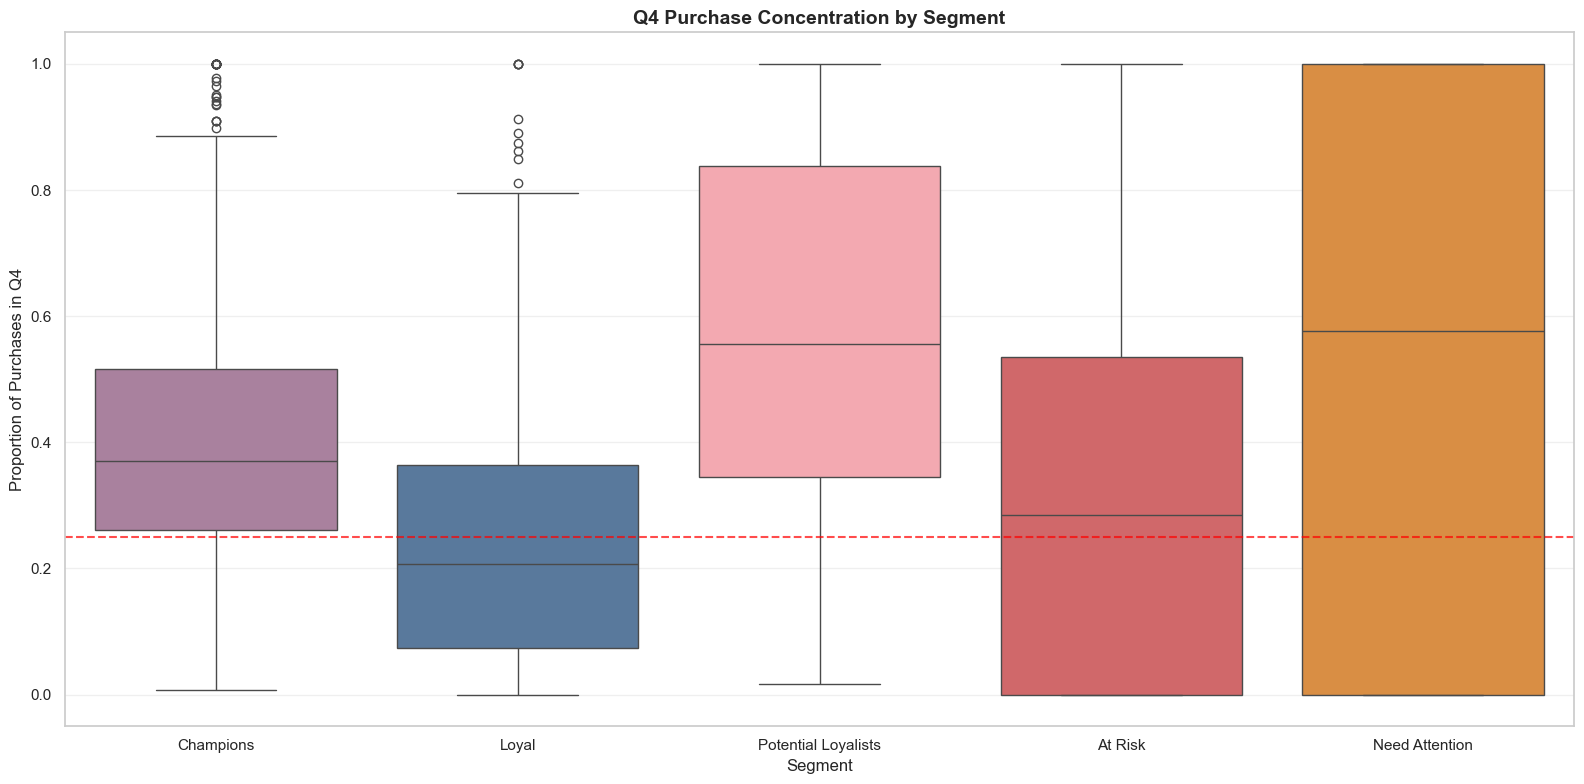

In [20]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=q4_concentration[q4_concentration['Segment'].isin(segment_order)],
    x='Segment',
    y='Q4_Concentration',
    order=segment_order,
    hue='Segment',
    palette=segment_colors,
    legend=False
)

# Reference line
plt.axhline(y=0.25, color='red', linestyle='--', alpha=0.7)

# Formatting
plt.ylabel('Proportion of Purchases in Q4')
plt.title('Q4 Purchase Concentration by Segment')
plt.tick_params(axis='x')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("../reports/figures/churn_by_segment.png", bbox_inches="tight")
plt.show()

The boxplot confirms and quantifies the seasonal profile analysis.

**Loyal** has the lowest median Q4 concentration (~0.20) and the 
tightest IQR of all segments, sitting mostly below the 0.25 
reference line. Low Q4 concentration is consistent across the 
entire segment, not just an average effect.

**Need Attention** shows the most striking distributional pattern, 
an IQR spanning nearly the full 0–1 range with a median around 
0.58. This extreme variance reflects a highly heterogeneous segment: 
some customers have near-zero Q4 concentration while others 
purchase exclusively in Q4. The wide spread, combined with the 
dramatic November spike in the line plot, confirms Need Attention 
is not a single behavioral archetype but a mix of seasonal buyers 
captured by the same low-engagement rule.

**Potential Loyalists** show a high median (~0.55) with a compressed 
upper quartile extending to 0.83. The majority of this segment 
concentrates more than half their purchases in Q4, confirming 
episodic seasonal purchasing as their defining characteristic.

**At Risk** sits at a moderate median (~0.28) with wide spread. 
A heterogeneous group of previously engaged customers with varying 
seasonal patterns.

**Champions** show a moderate median (~0.37) with a relatively 
compact IQR, reflecting meaningful year-round activity with a 
mild Q4 preference.

The Loyal vs all other segments contrast is the clearest signal: 
Loyal is the only segment with consistently low Q4 concentration 
across its entire distribution. Every other segment shows either 
high median Q4 concentration or extreme variance. This distributional 
uniqueness strengthens the case that the Loyal segment represents 
a genuinely distinct behavioral group whose high churn rate under 
the static definition is a measurement artifact rather than true 
attrition.

### 5.4 Segment renaming

Based on the seasonality analysis, one segment label is refined 
to better reflect observed behavior.

**Potential Loyalists → Seasonal High-Value**: this segment 
shows extreme Q4 concentration with near-zero activity outside 
the holiday period, indicating episodic seasonal purchasing 
rather than a progression toward consistent engagement. The 
original label implies an upward loyalty trajectory that the 
data does not support.

**Loyal** is retained unchanged. Despite its anomalous churn 
rate under the static definition, the flat seasonal profile 
and lowest Q4 concentration of any segment confirms these are 
genuine year-round buyers. The high churn rate is a measurement 
artifact of the snapshot approach, not true attrition.

**Need Attention** is not renamed but its behavioral profile 
is now better understood. It captures a heterogeneous mix 
of highly seasonal buyers rather than simply low-engagement 
customers. This has implications for retention strategy: 
contacting Need Attention customers outside Q4 is unlikely 
to be effective, as their purchasing behavior is structurally 
concentrated in the holiday period.

In [20]:
# Define renaming mapping
segment_rename = {
    'Potential Loyalists': 'Seasonal High-Value',  # Extreme Q4 concentration
}

# Apply renaming to all relevant dataframes
rfm_seg['Segment'] = rfm_seg['Segment'].replace(segment_rename)
q4_concentration['Segment'] = q4_concentration['Segment'].replace(segment_rename)
monthly_by_segment['Segment'] = monthly_by_segment['Segment'].replace(segment_rename)

### 5.5 Summary

The seasonality investigation resolves the Loyal segment anomaly 
and surfaces an unexpected finding about the Need Attention segment:

- **Loyal** customers purchase consistently year-round (7–10% 
  per month) with the lowest Q4 concentration of any segment. 
  Their 67.6% churn rate under the static 90-day definition is 
  a measurement artifact. The snapshot catches them between 
  purchase cycles rather than after genuine disengagement
- **Need Attention** is the most surprisingly seasonal segment.
  Despite having below-average churn (23.5%), its seasonal profile 
  is nearly identical to Potential Loyalists, with both segments 
  spiking to ~30% in November and remaining near-zero outside Q4.
- **Potential Loyalists** are relabeled Seasonal High-Value to 
  reflect their episodic Q4-driven behavior, nearly identical 
  in profile to Need Attention

These findings reinforce the limitation of static churn definitions 
and motivate the sliding window approach used in the feature 
engineering notebook.

## 4.5 Churned vs. Active Comparison

> ⚠️ Important Note on Recency and Data Leakage
>
> Recency is directly used in the definition of churn (customers are labeled as churned if their recency exceeds 90 days). As a result, the strong separation observed in Recency between churned and active customers is expected and should not be interpreted as an independent predictive signal.
>
> In subsequent modeling, care will be taken to avoid data leakage by ensuring that all features are computed strictly within the observation window and do not incorporate future information.

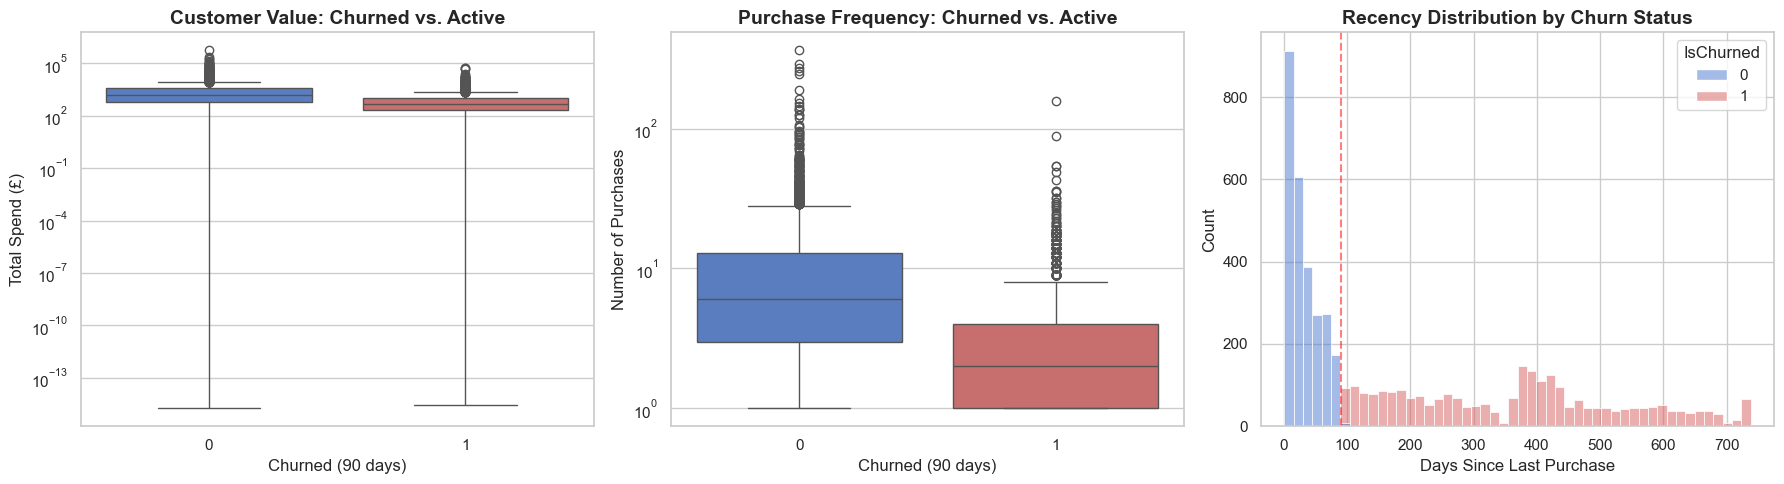

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Monetary value comparison
sns.boxplot(
    data=rfm,
    x='IsChurned',
    y='Monetary',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    legend=False,
    ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title('Customer Value: Churned vs. Active')
axes[0].set_xlabel(f'Churned ({CHURN_THRESHOLD} days)')
axes[0].set_ylabel('Total Spend (£)')

# Frequency comparison
sns.boxplot(
    data=rfm,
    x='IsChurned',
    y='Frequency',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    legend=False,
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Purchase Frequency: Churned vs. Active')
axes[1].set_xlabel(f'Churned ({CHURN_THRESHOLD} days)')
axes[1].set_ylabel('Number of Purchases')

# Recency distribution by churn status
sns.histplot(
    data=rfm,
    x='Recency',
    hue='IsChurned',
    bins=50,
    palette=CHURN_PALETTE,
    ax=axes[2]
)
axes[2].axvline(CHURN_THRESHOLD, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Recency Distribution by Churn Status')
axes[2].set_xlabel('Days Since Last Purchase')

plt.tight_layout()
plt.savefig("../reports/figures/churn_vs_active_rfm.png", bbox_inches="tight")
plt.show()

These plots show clear behavioral separation between churned and active customers.

Churned customers exhibit lower monetary value and significantly lower purchase frequency, with medians visibly below active customers. The frequency gap is particularly strong, suggesting engagement intensity is a key differentiator. Recency shows almost perfect separation due to the 90-day rule, confirming it is structurally tied to the churn definition.

Overall, churn is strongly associated with low frequency and lower spend, indicating that disengagement precedes attrition. Frequency appears to be the most informative non-leakage predictor among RFM variables.

## 4.6 Temporal Behavior & Engagement Dynamics

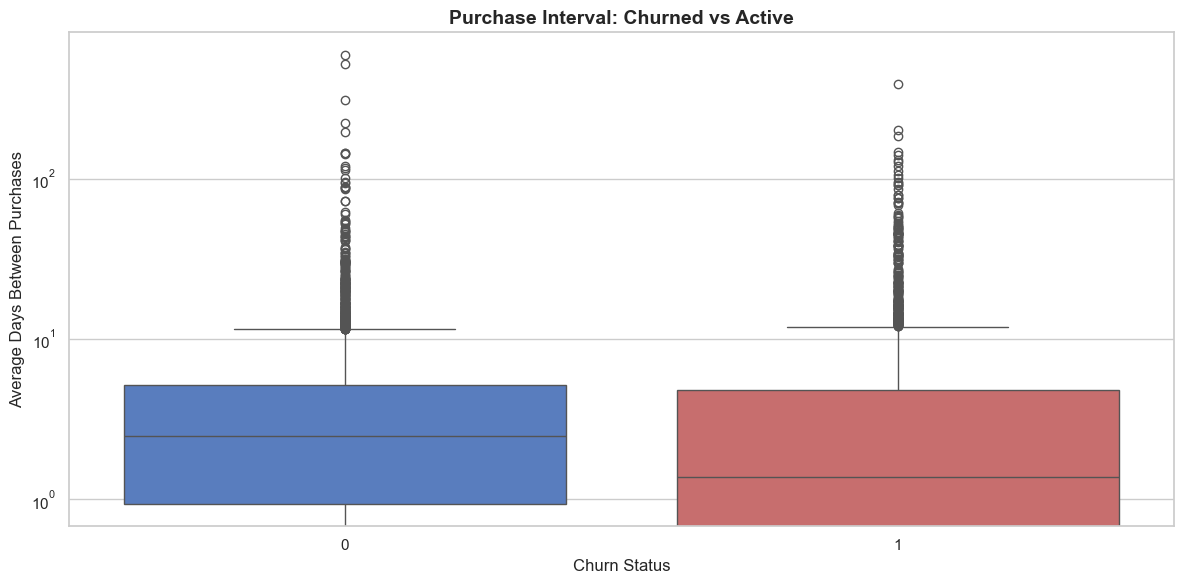

In [22]:
# Average interpurchase time per customer
purchase_intervals = uk_df_sorted.groupby('CustomerID')['InterpurchaseDays'].mean().reset_index()
purchase_intervals.columns = ['CustomerID', 'AvgInterpurchaseDays']

# Merge with churn labels
purchase_intervals = purchase_intervals.merge(
    rfm[['CustomerID', 'IsChurned']], 
    on='CustomerID'
)

# Plot
sns.boxplot(
    data=purchase_intervals,
    x='IsChurned',
    y='AvgInterpurchaseDays',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    legend=False
)

plt.yscale('log')
plt.title('Purchase Interval: Churned vs Active')
plt.xlabel('Churn Status')
plt.ylabel('Average Days Between Purchases')

plt.tight_layout()
plt.show()

The slightly lower average interpurchase time observed for churned customers may appear counterintuitive, but is explained by the difference between historical behavior and recent activity.

Churn is defined based on recent inactivity, while average interpurchase time reflects past purchasing patterns. Customers who were previously active over a short period and then stopped purchasing can exhibit low average intervals while still being classified as churned.

This highlights that churn is driven by the cessation of activity rather than slower purchasing frequency, reinforcing the importance of recent behavioral signals over historical averages.

## 4.7 Behavioral Pattern Analysis

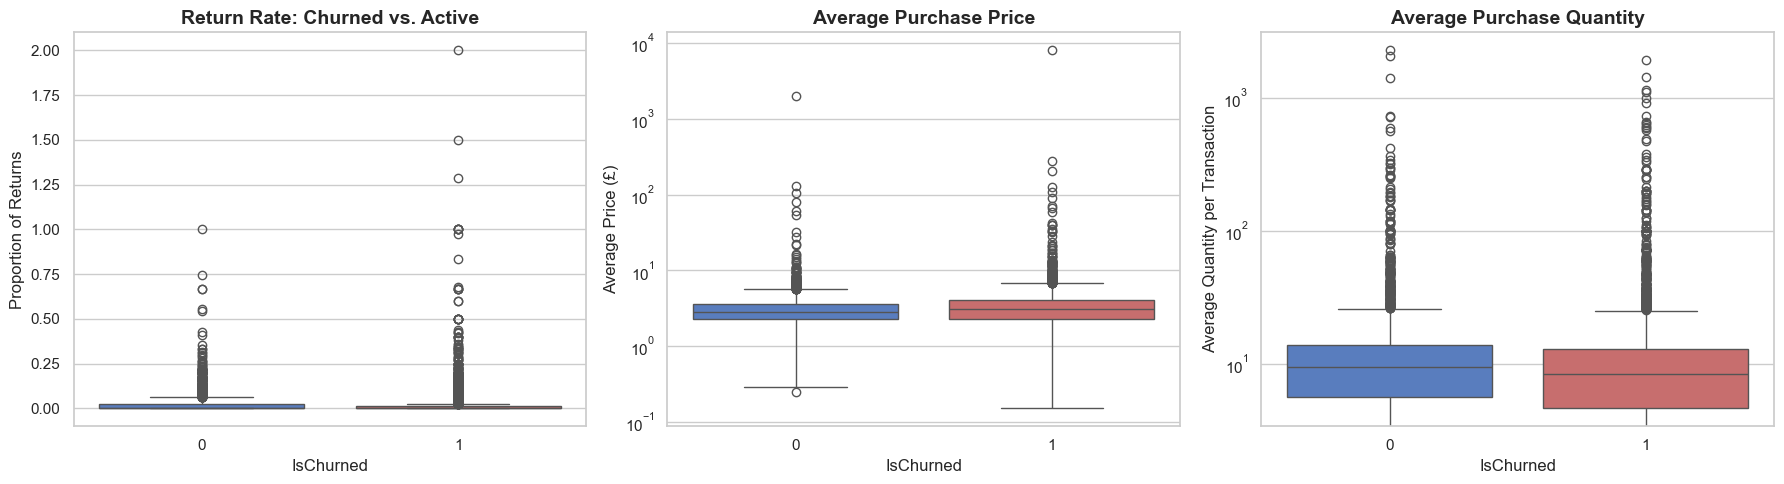

In [23]:
# Calculate behavioral metrics per customer
behavior = uk_df.groupby('CustomerID').agg({
    'Quantity': ['mean', 'sum'],
    'Price': ['mean', 'std'],
    # Only perform the ratio on the Standard Purchases
    'TransactionType': lambda x: (
        x.isin(['Linked_Return', 'Unlinked_Return']).sum() /
        # Avoid division by zero
        max((x == 'Standard_Purchase').sum(), 1)
    )
}).reset_index()

behavior.columns = ['CustomerID', 'AvgQty', 'TotalQty', 'AvgPrice', 'PriceStd', 'ReturnRate']

# Merge with churn labels
behavior = behavior.merge(rfm[['CustomerID', 'IsChurned']], on='CustomerID')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Return rate comparison
sns.boxplot(
    data=behavior,
    x='IsChurned',
    y='ReturnRate',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Return Rate: Churned vs. Active')
axes[0].set_ylabel('Proportion of Returns')

# Average price comparison
sns.boxplot(
    data=behavior,
    x='IsChurned',
    y='AvgPrice',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    legend=False,
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Average Purchase Price')
axes[1].set_ylabel('Average Price (£)')

# Quantity comparison
sns.boxplot(
    data=behavior,
    x='IsChurned',
    y='AvgQty',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    legend=False,
    ax=axes[2]
)
axes[2].set_yscale('log')
axes[2].set_title('Average Purchase Quantity')
axes[2].set_ylabel('Average Quantity per Transaction')

plt.tight_layout()
plt.show()

Return rate is low overall and shows no meaningful separation between churned and active customers, suggesting it is not a primary driver of churn.

Average purchase price is slightly lower for churned customers, but the difference is modest and unlikely to be a strong predictive signal. Similarly, average quantity per transaction exhibits high variability with substantial overlap between groups, indicating limited discriminatory power.

Overall, transactional characteristics such as price, quantity, and returns provide weak signals. In contrast, churn appears to be driven primarily by engagement intensity, reinforcing that declining activity (not purchasing style) is the key indicator of customer attrition.

## 5. Temporal Dynamics

### 5.1 Cohort Analysis

Analyze customer retention over time to identify cohort-level patterns.

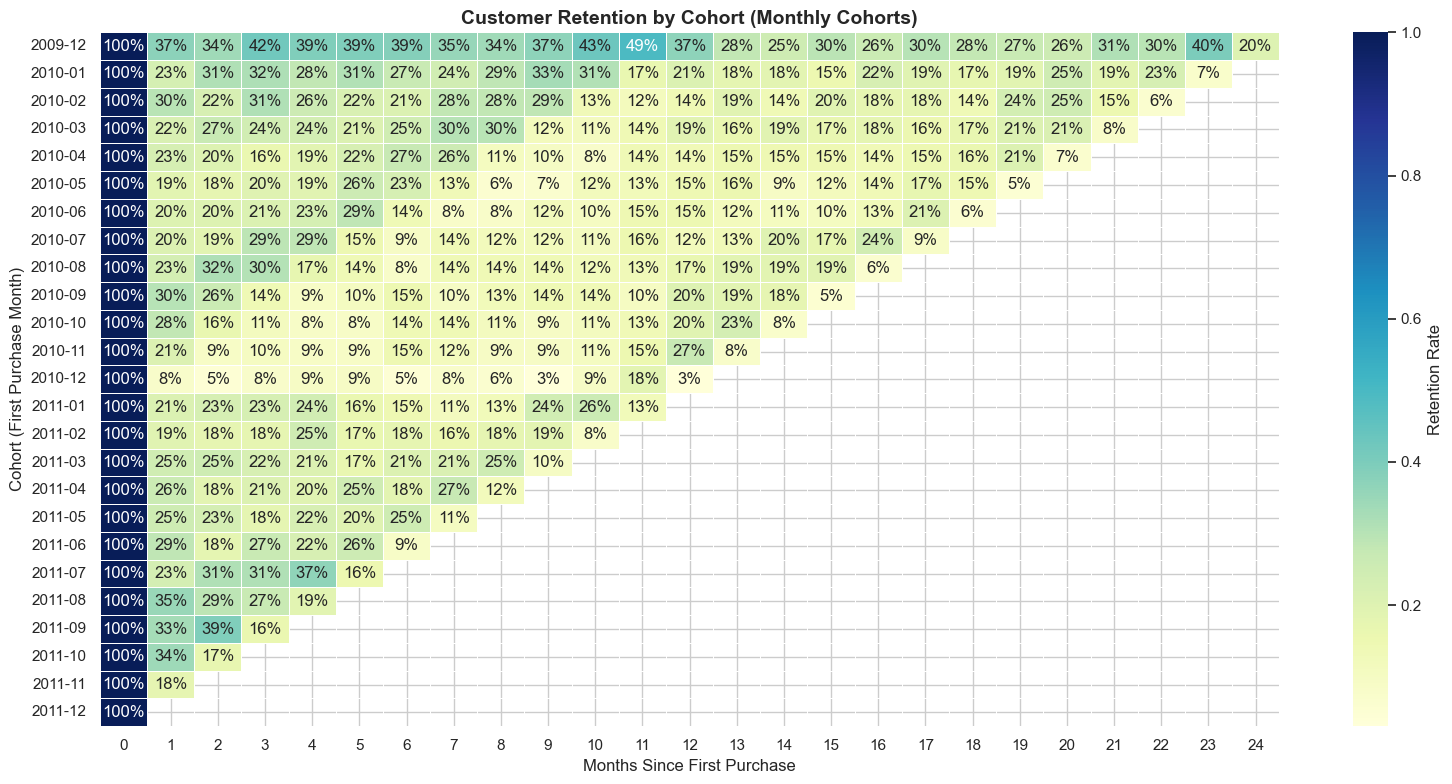

In [24]:
# Create cohort dataframe
cohort_df = uk_df.copy()

# Create cohort groups
cohort_df['InvoiceMonth'] = cohort_df['InvoiceDate'].dt.to_period('M')

customer_cohort = cohort_df.groupby('CustomerID')['InvoiceMonth'] \
    .min() \
    .reset_index() \
    .rename(columns={'InvoiceMonth': 'CohortMonth'})

# Merge cohort info
cohort_df = cohort_df.merge(customer_cohort, on='CustomerID')

# Calculate cohort index (months since first purchase)
cohort_df['CohortIndex'] = (
    cohort_df['InvoiceMonth'] - cohort_df['CohortMonth']
).apply(lambda x: x.n)

# Build retention matrix
cohort_data = cohort_df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'] \
    .nunique() \
    .reset_index()

retention_matrix = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

# Convert to percentages
cohort_sizes = retention_matrix.iloc[:, 0]
retention_pct = retention_matrix.divide(cohort_sizes, axis=0)

# Plot
plt.figure(figsize=(16, 8))
sns.heatmap(
    retention_pct,
    annot=True,
    fmt='.0%',
    cmap='YlGnBu',
    cbar_kws={'label': 'Retention Rate'},
    linewidths=0.5,
    linecolor='white'
)

plt.title('Customer Retention by Cohort (Monthly Cohorts)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort (First Purchase Month)')

plt.tight_layout()
plt.savefig("../reports/figures/cohort_retention.png", bbox_inches="tight")
plt.show()

Retention drops sharply after the first month across nearly all cohorts, indicating weak early loyalty and a high proportion of one-time or short-term buyers. After the initial decline, retention stabilizes at relatively low levels, suggesting that customers who survive the first few months are more likely to remain engaged long term.

There is some variability across cohorts, but no clear structural improvement over time.

Overall, the key insight is that churn is heavily front-loaded. Early lifecycle engagement appears critical, making the first 1–3 months the most important intervention window.

### 5.2 Seasonality Analysis
Objective: Quantify the impact of Q4 on purchasing behavior.

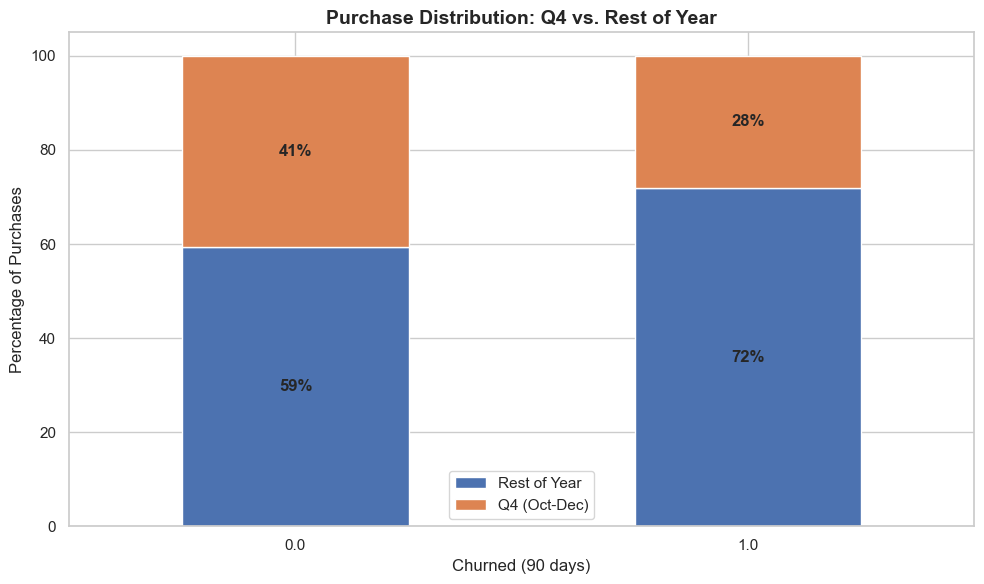

In [25]:
seasonality_churn_df = seasonality_df.merge(rfm[['CustomerID', 'IsChurned']], on='CustomerID', how='left')

# Calculate Q4 purchase percentage by churn status
q4_by_churn = seasonality_churn_df.groupby(['IsChurned', 'IsQ4'])['Invoice'].count().unstack()
q4_pct = q4_by_churn.div(q4_by_churn.sum(axis=1), axis=0) * 100

# Plot
ax = q4_pct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Purchase Distribution: Q4 vs. Rest of Year')
plt.xlabel(f'Churned ({CHURN_THRESHOLD} days)')
plt.ylabel('Percentage of Purchases')
plt.legend(['Rest of Year', 'Q4 (Oct-Dec)'])
plt.xticks(rotation=0)

# Add value labels
for i, (idx, row) in enumerate(q4_pct.iterrows()):
    ax.text(i, row.iloc[0]/2, f"{row.iloc[0]:.0f}%", ha='center', va='center', fontweight='bold')
    ax.text(i, row.iloc[0] + row.iloc[1]/2, f"{row.iloc[1]:.0f}%", ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Active customers (0) have 41% of purchases in Q4, while churned customers (1) have only 28% in Q4. That means active customers are more concentrated in the holiday period, not churned ones.

This suggests that retained customers may be more engaged during peak season and continue purchasing beyond it. Churned customers, on the other hand, appear less tied to Q4 and may represent more sporadic or low-engagement buyers overall.

So the insight shifts: seasonality alone does not explain churn. Sustained engagement beyond peak periods likely differentiates active customers.

### 5.3 Customer Tenure Analysis

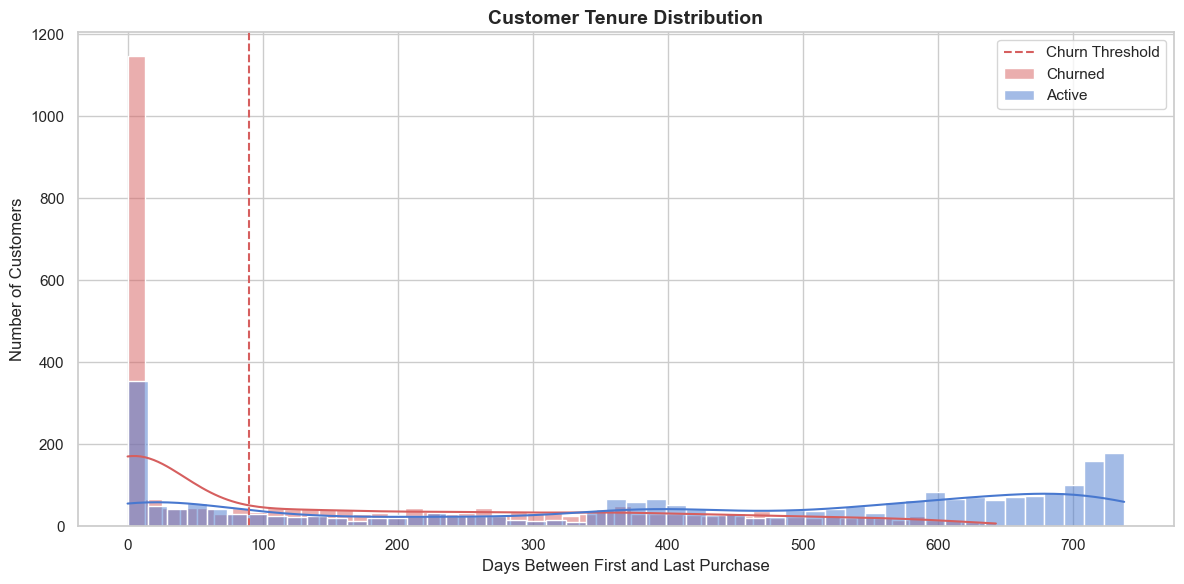

In [26]:
# Calculate customer lifetime
tenure = uk_df.groupby('CustomerID').agg({
    'InvoiceDate': ['min', 'max']
}).reset_index()
tenure.columns = ['CustomerID', 'FirstPurchase', 'LastPurchase']
tenure['TenureDays'] = (tenure['LastPurchase'] - tenure['FirstPurchase']).dt.days

tenure = tenure.merge(rfm[['CustomerID', 'IsChurned']], on='CustomerID')

# Plot
plt.figure(figsize=(12, 6))
sns.histplot(data=tenure[tenure['IsChurned']==1], x='TenureDays', bins=50, 
             color=COLOR_CHURNED, label='Churned', kde=True)
sns.histplot(data=tenure[tenure['IsChurned']==0], x='TenureDays', bins=50, 
             color=COLOR_RETAINED, label='Active', kde=True)

plt.axvline(CHURN_THRESHOLD, color=COLOR_CHURNED, linestyle='--', label=f'Churn Threshold')
plt.title('Customer Tenure Distribution')
plt.xlabel('Days Between First and Last Purchase')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

Churned customers are heavily concentrated at very low tenure, indicating many customers purchase once (or within a short window) and never return. Active customers, in contrast, are more distributed across longer tenures, with a visible concentration at high lifetime durations.

This reinforces the cohort insight: churn is strongly front-loaded. The main risk is early-stage attrition rather than long-term disengagement.

From a business perspective, improving early retention and post-first-purchase engagement would likely have the highest impact.

## 6. Customer Value vs Purchase Frequency

In [27]:
rfm['LogFrequency'] = np.log1p(rfm['Frequency'])
rfm['LogMonetary'] = np.log1p(rfm['Monetary'])

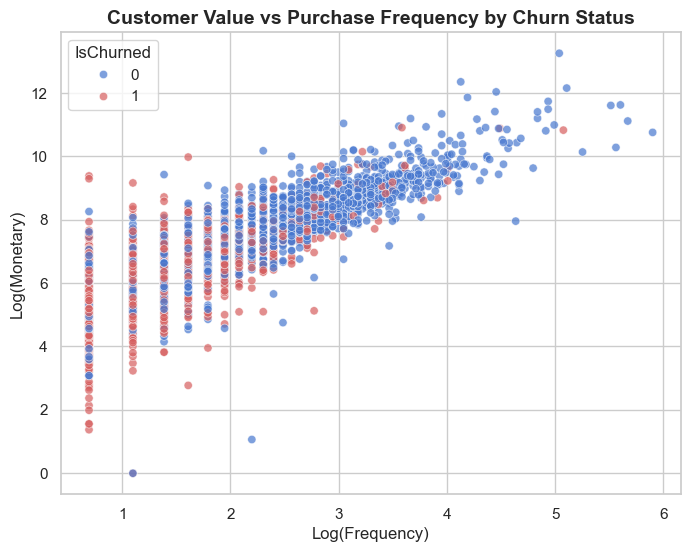

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='LogFrequency',
    y='LogMonetary',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    alpha=0.7
)

plt.title("Customer Value vs Purchase Frequency by Churn Status")
plt.xlabel("Log(Frequency)")
plt.ylabel("Log(Monetary)")

plt.savefig("../reports/figures/value_vs_frequency.png", bbox_inches="tight")
plt.show()

The plot shows a clear positive relationship between purchase frequency and monetary value. Customers who buy more frequently tend to generate higher revenue.

Churned customers are more concentrated in the lower frequency and lower spending region, while higher-value customers are mostly retained. This suggests that purchasing behavior is an important indicator of customer retention.

## 7. Statistical Validation of EDA Findings

While visual analysis suggests meaningful differences between churned and active customers, we formally test whether these differences are statistically significant.

Given the strong skewness in behavioral variables, non-parametric tests are used.

Significance level α = 0.05

### 7.1 Mann–Whitney U Test (Frequency/Monetary)
We test whether Frequency and Monetary differ between churned and active customers.

In [29]:
active_freq = rfm[rfm["IsChurned"] == 0]["Frequency"]
churned_freq = rfm[rfm["IsChurned"] == 1]["Frequency"]

stat, p = mannwhitneyu(active_freq, churned_freq, alternative="two-sided")

n1 = len(active_freq)
n2 = len(churned_freq)
effect_size = stat / (n1 * n2)

print("Frequency")
print("-"*40)
print("U-statistic:", stat)
print("p-value:", p)
print("Effect size:", effect_size)

Frequency
----------------------------------------
U-statistic: 5326440.5
p-value: 3.515635526662726e-229
Effect size: 0.7534458882174543


In [30]:
active_mon = rfm[rfm["IsChurned"] == 0]["Monetary"]
churned_mon = rfm[rfm["IsChurned"] == 1]["Monetary"]

stat, p = mannwhitneyu(active_mon, churned_mon, alternative="two-sided")

n1 = len(active_mon)
n2 = len(churned_mon)
effect_size = stat / (n1 * n2)

print("Monetary")
print("-"*40)
print("U-statistic:", stat)
print("p-value:", p)
print("Effect size:", effect_size)

Monetary
----------------------------------------
U-statistic: 5335160.0
p-value: 5.741900536885438e-227
Effect size: 0.7546792956726417


**Interpretation**: Both Frequency and Monetary differ significantly between churned and active customers (p < 0.001). Large effect sizes (~0.75) indicate strong practical significance, confirming that active customers consistently exhibit higher engagement and spending.

### 7.2 Chi-Square Test (Seasonality)
We test whether Q4 purchasing behavior is associated with churn.

In [31]:
chi2, p_value, dof, expected_frequencies = chi2_contingency(q4_by_churn)

n = q4_by_churn.values.sum()
phi2 = chi2 / n
r, k = q4_by_churn.shape
cramers_v = np.sqrt(phi2 / (min(r - 1, k - 1)))

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Cramer's V:", cramers_v)

Chi-square statistic: 8261.91959205962
p-value: 0.0
Cramer's V: 0.10745918781597796


**Interpretation**: The association between Q4 purchasing behavior and churn is statistically significant (p < 0.001), but the effect size (Cramér’s V = 0.108) is small, indicating that seasonality has a limited influence compared to engagement-based factors.

### 7.3 Mann–Whitney U Test (Segment-Level Seasonality)

Building on the RFM segmentation findings, we formally test whether the Loyal segment's Q4 concentration differs significantly from other key segments. This validates our hypothesis that the Loyal segment's high churn rate is a definition artifact rather than true attrition.

In [32]:
# Extract Q4 concentration for key segments (using renamed segments)
consistent_buyers_q4 = q4_concentration[q4_concentration['Segment'] == 'Loyal']['Q4_Concentration']
vip_q4 = q4_concentration[q4_concentration['Segment'] == 'Champions']['Q4_Concentration']
seasonal_high_value_q4 = q4_concentration[q4_concentration['Segment'] == 'Seasonal High-Value']['Q4_Concentration']
at_risk_q4 = q4_concentration[q4_concentration['Segment'] == 'At Risk']['Q4_Concentration']
need_attention_q4 = q4_concentration[q4_concentration['Segment'] == 'Need Attention']['Q4_Concentration']
hibernating_q4 = q4_concentration[q4_concentration['Segment'] == 'Hibernating']['Q4_Concentration']

print("Segment-Level Seasonality Validation")
print("-"*40)

def print_test_result(title, p, effect):
    significance = "✓ Significant" if p < 0.05 else "✗ Not significant"
    
    print(f"{title}")
    print(f"   p-value     : {p:.4f}")
    print(f"   Effect size : {effect:.3f}")
    print(f"   Significance: {significance}")
    print()  # blank line for spacing

# Test 1: Loyal vs Champions
stat_1, p_1 = mannwhitneyu(consistent_buyers_q4, vip_q4, alternative='two-sided')
n1, n2 = len(consistent_buyers_q4), len(vip_q4)
effect_1 = stat_1 / (n1 * n2)

print_test_result("1. Loyal vs Champions", p_1, effect_1)

# Test 2: Loyal vs Seasonal High-Value
stat_2, p_2 = mannwhitneyu(consistent_buyers_q4, seasonal_high_value_q4, alternative='two-sided')
n1, n2 = len(consistent_buyers_q4), len(seasonal_high_value_q4)
effect_2 = stat_2 / (n1 * n2)

print_test_result("2. Loyal vs Seasonal High-Value", p_2, effect_2)

# Test 3: Loyal vs At Risk
stat_3, p_3 = mannwhitneyu(consistent_buyers_q4, at_risk_q4, alternative='two-sided')
n1, n2 = len(consistent_buyers_q4), len(at_risk_q4)
effect_3 = stat_3 / (n1 * n2)

print_test_result("3. Loyal vs At Risk", p_3, effect_3)

# Test 4: Loyal vs Need Attention
stat_4, p_4 = mannwhitneyu(consistent_buyers_q4, need_attention_q4, alternative='two-sided')
n1, n2 = len(consistent_buyers_q4), len(need_attention_q4)
effect_4 = stat_4 / (n1 * n2)

print_test_result("4. Loyal vs Need Attention", p_4, effect_4)

# Test 5: Loyal vs Hibernating
stat_5, p_5 = mannwhitneyu(consistent_buyers_q4, hibernating_q4, alternative='two-sided')
n1, n2 = len(consistent_buyers_q4), len(hibernating_q4)
effect_5 = stat_5 / (n1 * n2)

print_test_result("5. Loyal vs Hibernating", p_5, effect_5)

Segment-Level Seasonality Validation
----------------------------------------
1. Loyal vs Champions
   p-value     : 0.0000
   Effect size : 0.275
   Significance: ✓ Significant

2. Loyal vs Seasonal High-Value
   p-value     : 0.0000
   Effect size : 0.174
   Significance: ✓ Significant

3. Loyal vs At Risk
   p-value     : 0.0188
   Effect size : 0.455
   Significance: ✓ Significant

4. Loyal vs Need Attention
   p-value     : 0.0000
   Effect size : 0.345
   Significance: ✓ Significant

5. Loyal vs Hibernating
   p-value     : 0.0000
   Effect size : 0.583
   Significance: ✓ Significant



**Interpretation**: All comparisons show statistically significant differences between the Loyal segment and others (p < 0.05). Effect sizes indicate that Loyal customers exhibit distinct purchasing patterns, particularly compared to low-engagement segments.

- **Loyal vs Hibernating** shows the largest effect size (0.583), indicating a strong distinction between year-round consistent purchasers and low-engagement customers
- **Loyal vs At Risk** shows a substantial effect (0.455), confirming that Loyal Buyers' purchasing patterns are meaningfully different from those at risk of churn
- **Loyal vs Seasonal High-Value** shows the smallest effect (0.174), which is still statistically significant and reflects that both segments maintain engagement, though with fundamentally different seasonal patterns (year-round consistency vs extreme Q4 concentration)
- This confirms that the **Loyal** segment represents a distinct behavioral group—year-round purchasers—whose apparent 67.6% churn rate is a definition artifact rather than true attrition

The smaller effect size relative to Seasonal High-Value customers suggests both groups maintain engagement, but differ in seasonality patterns. This supports the interpretation that Loyal customers are consistent year-round buyers rather than seasonal shoppers.

### 7.4 Kruskal-Wallis Test (Multiple Segment Comparison)

To validate that all segments have distinct seasonal patterns, we perform a Kruskal-Wallis H-test across all segments simultaneously.

In [33]:
# Prepare data for all segments
segment_groups = []
segment_names = []
# TODO replace segment_order
for segment in segment_order:
    segment_data = q4_concentration[q4_concentration['Segment'] == segment]['Q4_Concentration']
    if len(segment_data) > 0:
        segment_groups.append(segment_data)
        segment_names.append(segment)

# Perform Kruskal-Wallis test
h_stat, p_value = kruskal(*segment_groups)

# Calculate epsilon-squared effect size
n_total = sum(len(group) for group in segment_groups)
epsilon_sq = (h_stat - (len(segment_groups) - 1)) / (n_total - len(segment_groups))

print("Multi-Segment Seasonality Validation")
print("-"*40)
print(f"Kruskal-Wallis H-test:")
print(f"  p-value: {p_value:.4f}")
print(f"  Effect size: {epsilon_sq:.3f}")
print(f"  Significance: {'✓ Significant' if p_value < 0.05 else '✗ Not significant'}")

Multi-Segment Seasonality Validation
----------------------------------------
Kruskal-Wallis H-test:
  p-value: 0.0000
  Effect size: 0.076
  Significance: ✓ Significant


**Interpretation**: The Kruskal-Wallis test confirms that at least one segment differs significantly from the others (p < 0.001). The effect size (ε² = 0.079) indicates a small-to-moderate effect, suggesting the presence of distinct seasonal patterns across segments.

While the differences are statistically significant, the moderate magnitude of the effect indicates that seasonality contributes to behavioral variation but is not the dominant driver compared to engagement-based factors.

### 7.5 Statistical Validation Summary

1. **Primary Drivers of Churn**: Engagement intensity (Frequency) and accumulated value (Monetary) are the strongest predictors of churn, with large effect sizes (>0.75)
2. **Seasonality's Limited Role**: While statistically significant, seasonality has only a small-to-moderate association with churn (Cramér's V = 0.107), suggesting it's not the primary driver
3. **Loyal Segment Validation**: The Loyal segment's Q4 concentration is statistically distinct from all other segments, confirming they represent a unique customer type: consistent year-round buyers
4. **Definition Artifact Confirmed**: The 67.6% churn rate in the Loyal segment is not due to true attrition but rather the interaction between their consistent purchasing pattern and the static 90-day inactivity window

## 8. Modeling Hypotheses

Based on the exploratory analysis, we formulate the following hypotheses to guide feature engineering and model development:

- **H1**: Engagement intensity is the primary driver of churn  
  Customers with low purchase frequency are significantly more likely to churn.

- **H2**: Early lifecycle behavior is critical  
  Customers who do not engage beyond their first purchase represent a high-risk segment.

- **H3**: Behavioral change signals churn risk  
  Declines in purchase frequency or spending over time are strong indicators of impending churn.

- **H4**: Monetary value provides additional signal but is secondary to frequency  
  High-value customers are less likely to churn, but engagement remains the dominant factor.

- **H5**: Seasonality influences behavior but is not a primary driver of churn  
  Seasonal purchasing patterns can distort churn labels but do not fully explain customer attrition.

These hypotheses will be tested in the feature engineering and modeling stages using a time-aware validation framework.

## 9. EDA Summary

Churn is primarily driven by engagement intensity, with purchase frequency emerging as the strongest differentiator. Monetary value adds signal but is largely correlated with frequency.

Churn appears as a gradual disengagement process, where recent inactivity and behavioral changes matter more than long-term averages.

Seasonality and transaction-level features show limited impact, while churn is heavily front-loaded in the customer lifecycle, highlighting the importance of early engagement.

Overall, these findings suggest that effective churn prediction requires time-aware features capturing recent activity and behavioral trends.

## 10. Candidate Features for Modeling

Based on the insights derived from EDA, the following feature groups are proposed for the churn prediction model:

**Engagement features**
- Purchase frequency over multiple time windows
- Time since last purchase (recency within window)
- Number of active purchase periods

**Behavioral trend features**
- Change in purchase frequency over time
- Change in spending over time
- Acceleration or decay in activity

**Lifecycle features**
- Number of purchases in the first 30 days
- Time since first purchase
- Early engagement intensity

**Seasonality features**
- Proportion of purchases in Q4
- Preferred purchase month

**Behavioral consistency features**
- Average time between purchases
- Variability in purchase intervals

These features are designed to capture both **static customer characteristics** and **dynamic behavioral changes**, which are essential for predicting churn in a temporal setting.